In [1]:
# Merge & clean "activity" table from database

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

out_figures_path = "../../generated/figures/database"
if not os.path.exists(out_figures_path):
    os.makedirs(out_figures_path)

out_generated_path = "../../generated/database"
if not os.path.exists(out_generated_path):
    os.makedirs(out_generated_path)

In [3]:
activity = "../../data/database/activity.csv"
df = pd.read_csv(activity)

game_mode = "../../data/database/game_mode.csv"
df_game_mode = pd.read_csv(game_mode)

df = df.merge(df_game_mode, left_on="game_mode", right_on="id", how="left")

df["game_mode"] = df["name"]
df = df.drop(columns=["id_x", "id_y", "name"])
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_convert("Europe/Brussels")

df_without_group = df[[col for col in df.columns if col != 'timestamp'] + ['timestamp']]

In [4]:
count_df = df_without_group.groupby('achievement').size().reset_index(name='count').sort_values(by='count', ascending=False)
count_df.to_csv(f"{out_generated_path}/achievements-count.csv", index=False)

# Add group

In [5]:
users_groups = df_without_group[['user', 'game_mode']].drop_duplicates()
users_groups

,user,game_mode
0,70e85b5e-92d4-498a-9079-ba881f5b3b82,TEAM
1,960ad9f8-2b83-4526-9cfb-1a59cec049a6,SOLO
2,0d271530-be17-4538-bf04-dde3c6069b5f,SOLO
3,fb270a09-6a45-4eae-8f9a-3c808faec3ee,TEAM
4,c27240eb-52c0-4436-aa0f-e7f97a94a725,TEAM
5,84c2c4e6-1c27-4f2c-808b-9e84a7cb257e,SOLO
6,7234f6dc-a316-4576-8453-6e10d7cf1c3d,SOLO
8,11555248-3f01-4d1c-9a71-ef7caf9150fa,SOLO
9,eda1acdb-c4bb-4425-a39f-4c25a998e739,SOLO
10,bcec21aa-2246-4ee8-9f2a-3998a5cde697,TEAM


In [6]:
df_users = pd.read_csv('../../data/database/user.csv')
df_users['created_at'] = pd.to_datetime(df_users['created_at'], utc=True).dt.tz_convert("Europe/Brussels")
df_users['last_update'] = pd.to_datetime(df_users['last_update'], utc=True).dt.tz_convert("Europe/Brussels")

users = df_users.merge(users_groups, left_on='id', right_on='user', how='left')
users = users.drop(columns=['user'])
users = users.rename(columns={'id': 'user'})
users.to_csv(f"{out_generated_path}/users.csv", index=False)
users[pd.isnull(users["game_mode"])].to_csv(f"{out_generated_path}/users_no_activity.csv", index=False)

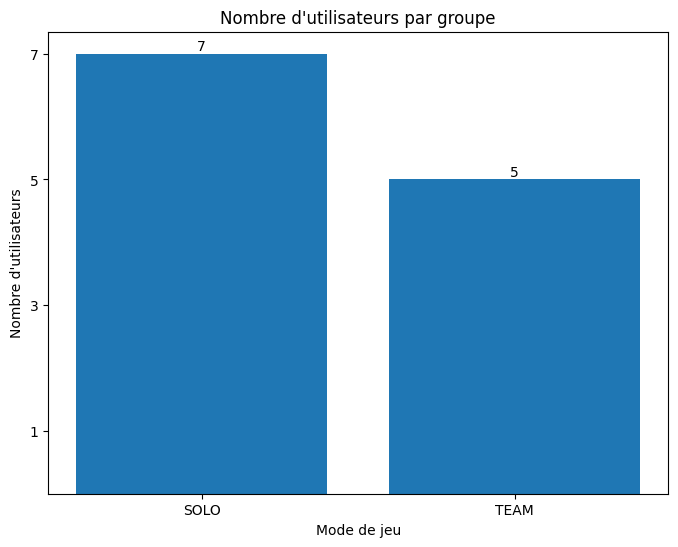

In [7]:
group_counts = users_groups['game_mode'].value_counts()
group_counts
plt.figure(figsize=(8, 6))
plt.bar(group_counts.index, group_counts.values)
plt.title('Nombre d\'utilisateurs par groupe')
plt.xlabel('Mode de jeu')
plt.ylabel('Nombre d\'utilisateurs')
plt.yticks(range(1, int(max(group_counts)) + 1, 2))

for i, v in enumerate(group_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.savefig(f"{out_figures_path}/group_counts.pdf")
plt.show()

In [8]:
user_achievements = users.merge(df, left_on='user', right_on='user', how='left')
user_achievements.rename(columns={'game_mode_x': 'game_mode'}, inplace=True)
user_achievements

,user,created_at,last_update,game_mode,achievement,game_mode_y,timestamp
0,11555248-3f01-4d1c-9a71-ef7caf9150fa,2026-04-16 11:12:53.421000+02:00,2026-04-16 11:12:53.421000+02:00,SOLO,Add1TestAchievement,SOLO,2026-04-16 11:33:12.311968+02:00
1,11555248-3f01-4d1c-9a71-ef7caf9150fa,2026-04-16 11:12:53.421000+02:00,2026-04-16 11:12:53.421000+02:00,SOLO,Add10TestsAchievement,SOLO,2026-04-16 12:30:15.352811+02:00
2,11555248-3f01-4d1c-9a71-ef7caf9150fa,2026-04-16 11:12:53.421000+02:00,2026-04-16 11:12:53.421000+02:00,SOLO,Cover10LinesAchievement,SOLO,2026-04-16 12:30:43.772523+02:00
3,70e85b5e-92d4-498a-9079-ba881f5b3b82,2026-04-16 11:12:53.422000+02:00,2026-04-16 11:12:53.422000+02:00,TEAM,Add1TestAchievement,TEAM,2026-04-16 11:20:58.636937+02:00
4,70e85b5e-92d4-498a-9079-ba881f5b3b82,2026-04-16 11:12:53.422000+02:00,2026-04-16 11:12:53.422000+02:00,TEAM,Cover10LinesAchievement,TEAM,2026-04-16 11:40:26.788686+02:00
...,...,...,...,...,...,...,...
66,fb270a09-6a45-4eae-8f9a-3c808faec3ee,2026-04-16 11:13:31.320000+02:00,2026-04-16 12:25:23.436000+02:00,TEAM,Cover10LinesAchievement,TEAM,2026-04-16 11:55:06.132810+02:00
67,fb270a09-6a45-4eae-8f9a-3c808faec3ee,2026-04-16 11:13:31.320000+02:00,2026-04-16 12:25:23.436000+02:00,TEAM,Add10TestsAchievement,TEAM,2026-04-16 12:01:23.723245+02:00
68,fb270a09-6a45-4eae-8f9a-3c808faec3ee,2026-04-16 11:13:31.320000+02:00,2026-04-16 12:25:23.436000+02:00,TEAM,Kill1MutantAchievement,TEAM,2026-04-16 12:20:56.868069+02:00
69,fb270a09-6a45-4eae-8f9a-3c808faec3ee,2026-04-16 11:13:31.320000+02:00,2026-04-16 12:25:23.436000+02:00,TEAM,Kill5MutantsAchievement,TEAM,2026-04-16 12:20:56.888604+02:00


In [9]:
interaction_counts = user_achievements.groupby(['game_mode','user'])['achievement'].count().reset_index(name='achievement')
interaction_counts

,game_mode,user,achievement
0,SOLO,0d271530-be17-4538-bf04-dde3c6069b5f,5
1,SOLO,11555248-3f01-4d1c-9a71-ef7caf9150fa,3
2,SOLO,70c71a91-06a1-4bf4-8e56-f4327b1c8b3f,1
3,SOLO,7234f6dc-a316-4576-8453-6e10d7cf1c3d,10
4,SOLO,84c2c4e6-1c27-4f2c-808b-9e84a7cb257e,8
5,SOLO,960ad9f8-2b83-4526-9cfb-1a59cec049a6,5
6,SOLO,eda1acdb-c4bb-4425-a39f-4c25a998e739,5
7,TEAM,0947a22a-ec40-4f49-867b-330a623a1a35,10
8,TEAM,70e85b5e-92d4-498a-9079-ba881f5b3b82,8
9,TEAM,bcec21aa-2246-4ee8-9f2a-3998a5cde697,3


In [10]:
outlier_users_by_mode = []

for mode in user_achievements['game_mode'].unique():
        print(f"Mode : {mode}")
        mode_group_data = interaction_counts[
            (interaction_counts['game_mode'] == mode)
            ]['achievement']

        Q1 = mode_group_data.quantile(0.25)
        Q3 = mode_group_data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        print(f"\t{mode} - Bound: ({lower_bound}, {upper_bound})")

        data = mode_group_data[(mode_group_data < lower_bound) | (mode_group_data > upper_bound)]
        mode_group_outliers = data.index
        outlier_users = interaction_counts.iloc[mode_group_outliers]['user'].values
        print(f"\tOutliers: {data.values}  - {outlier_users}\n")
        outlier_users_by_mode.extend(outlier_users)

Mode : SOLO
	SOLO - Bound: (0.25, 10.25)
	Outliers: []  - <StringArray>
[]
Length: 0, dtype: str

Mode : TEAM
	TEAM - Bound: (3.0, 11.0)
	Outliers: []  - <StringArray>
[]
Length: 0, dtype: str

Mode : nan
	nan - Bound: (nan, nan)
	Outliers: []  - <StringArray>
[]
Length: 0, dtype: str



In [11]:
print(f"Outliers : {len(outlier_users)}")
print(outlier_users)
print("")

Outliers : 0
<StringArray>
[]
Length: 0, dtype: str



In [12]:
df.to_csv(f"{out_generated_path}/activity.csv", index=False)
df.to_csv(f"{out_generated_path}/activity-brut.csv", index=False)

In [13]:
df_coverage = pd.read_csv("../../data/database/coverage.csv")
df_coverage.replace({'game_mode': {0: 'SOLO'}}, inplace=True)
df_coverage.replace({'game_mode': {1: 'TEAM'}}, inplace=True)
df_coverage.to_csv(f"{out_generated_path}/coverage.csv", index=False)